<a href="https://colab.research.google.com/github/carlosmvond/Rocco_et_al_2026/blob/main/Rocco_et_al_2026_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integrating dynamic modeling and continuous cultivation to enhance recombinant β-glucosidase production in *Komagataella phaffii*

**Rocco-Martínez, Quezada *et al.* (2026) — analysis notebook**

This notebook reproduces every model-based result of the manuscript and the Supplementary Information from the raw batch and chemostat data. The cells are meant to be run **in order from top to bottom**; each block reuses the objects created by the previous ones.

| Block | Content | Output in the article |
|---|---|---|
| 1 | Data processing and visualization | Batch data overview (Fig. 1 A–C) |
| 2 | Reproducible setup, model and parameter estimation | **Table 1** |
| 3 | Model–data comparison and goodness-of-fit ($R^2$) | **Fig. 2** |
| 4 | Variable-specific RMSE, NRMSE, bias and residual diagnostics | **Fig. S6**, **Table S5** |
| 5 | Fitting the biological replicates explicitly | **Table S2** |
| 6 | Multi-start optimisation | **Fig. S4** |
| 7 | Profile likelihood of the kinetic parameters | **Fig. S3** |
| 8 | Comparison with a conventional Monod + Luedeking-Piret model | **Fig. S5** |
| 9 | Chemostat steady state ($dy/dt \approx 0$) and selection of dilution rates | **Fig. 3** |
| 10 | Model predictions vs. chemostat experimental data | **Fig. 4**, Table S1 data |
| 11 | Effect of the constants that were fixed ($K_S$, $z_0$, $z_{min}$) | **Tables S3 and S4** |

All figures are saved as 300 dpi PNG files in the folder `figures/`, and all tables are exported as CSV files in the folder `tables/`.

## 1. Data processing and visualization

This block contains the raw batch culture data obtained at 20, 25 and 30 °C (two biological replicates per condition): time, biomass, glucose, total secreted protein, BGL1 activity, temperature and replicate number.

For each temperature, the mean and standard deviation of biomass, total secreted protein and glucose are computed at every sampling time, and the averaged profiles are shown in a 3 × 3 grid (rows: temperature; columns: biomass, protein, substrate). Error bars represent ±1 standard deviation between the two biological replicates. These replicate-averaged profiles are the data used for model fitting in Block 2.

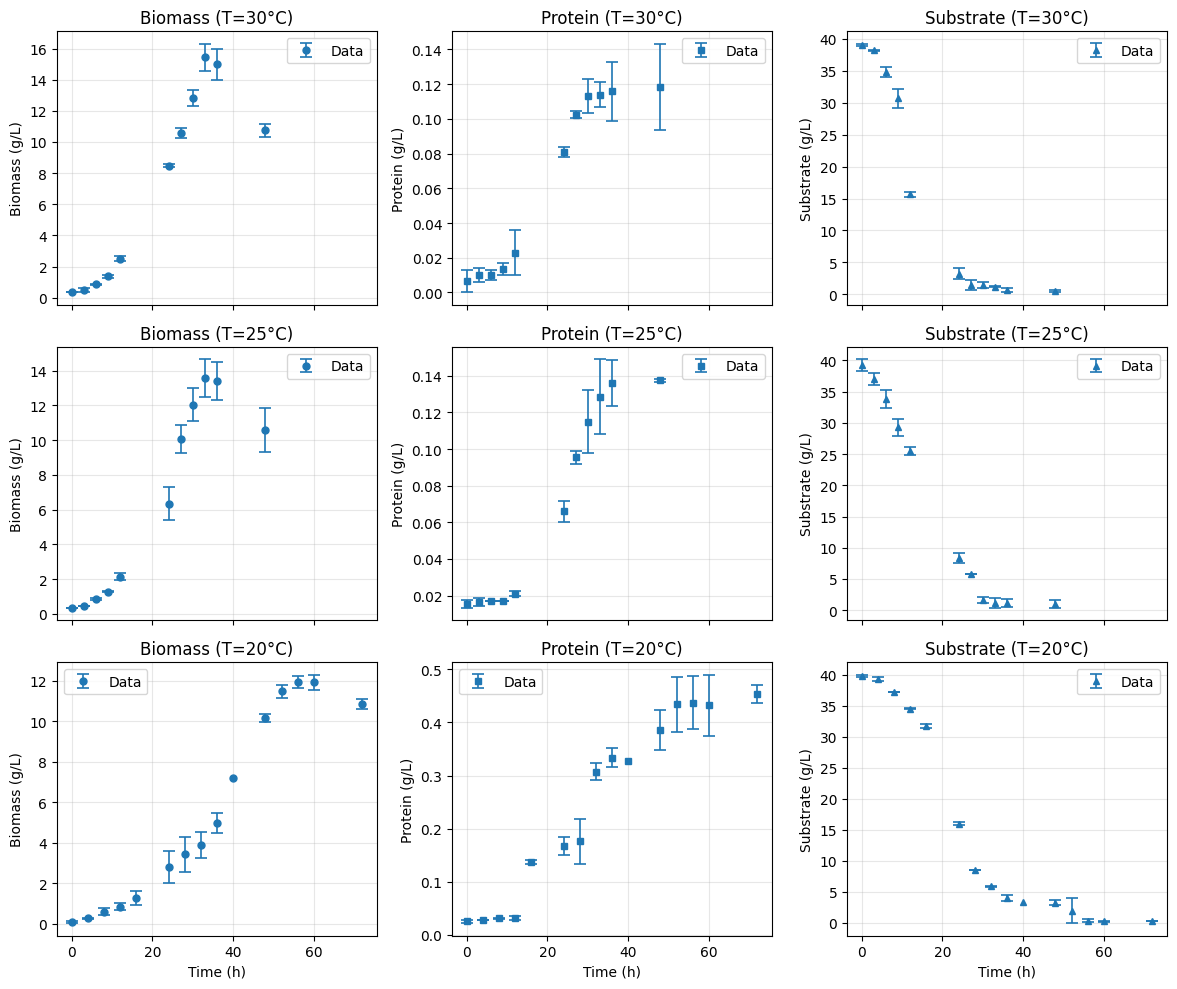

In [1]:
# =============================================================================
# 1. Data processing and visualization
# =============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)

# -----------------------------------------------------------------------------
# Raw batch data: [time (h), biomass (g/L), glucose (g/L), protein (g/L),
#                  activity (IU/L), temperature (°C), replicate]
# -----------------------------------------------------------------------------
data_rows = [
    # T = 30 °C, replicate 1
    [0, 0.36, 39.185, 0.002, 9.02, 30, 1],
    [3, 0.59, 38.268, 0.007, 2.25, 30, 1],
    [6, 0.85, 34.251, 0.008, 41.72, 30, 1],
    [9, 1.44, 29.667, 0.011, 22.55, 30, 1],
    [12, 2.60, 15.412, 0.014, 1346.19, 30, 1],
    [24, 8.54, 2.591, 0.079, 2095.95, 30, 1],
    [27, 10.82, 0.954, 0.101, 2259.43, 30, 1],
    [30, 12.46, 1.082, 0.120, 3133.21, 30, 1],
    [33, 14.81, 1.261, 0.119, 3296.69, 30, 1],
    [36, 14.29, 0.884, 0.128, 4204.30, 30, 1],
    [48, 10.47, 0.580, 0.136, 3245.96, 30, 1],
    # T = 30 °C, replicate 2
    [0, 0.36, 38.967, 0.011, 36.08, 30, 2],
    [3, 0.39, 38.137, 0.013, 92.45, 30, 2],
    [6, 0.88, 35.408, 0.012, 23.68, 30, 2],
    [9, 1.28, 31.676, 0.016, 29.31, 30, 2],
    [12, 2.38, 15.893, 0.032, 1261.63, 30, 2],
    [24, 8.43, 3.802, 0.083, 2157.96, 30, 2],
    [27, 10.36, 2.001, 0.104, 2941.54, 30, 2],
    [30, 13.2, 1.770, 0.106, 3065.56, 30, 2],
    [33, 16.05, 1.112, 0.109, 3302.33, 30, 2],
    [36, 15.7, 0.429, 0.104, 3093.75, 30, 2],
    [48, 11.05, 0.407, 0.101, 3505.27, 30, 2],
    # T = 25 °C, replicate 1
    [0, 0.35, 39.917, 0.014, 25.03, 25, 1],
    [3, 0.46, 37.684, 0.015, 25.37, 25, 1],
    [6, 0.8, 34.782, 0.017, 28.58, 25, 1],
    [9, 1.25, 30.272, 0.017, 25.88, 25, 1],
    [12, 1.99, 25.986, 0.022, 1347.03, 25, 1],
    [24, 5.67, 7.733, 0.070, 1170.30, 25, 1],
    [27, 9.47, 5.729, 0.093, 1604.94, 25, 1],
    [30, 11.35, 1.998, 0.103, 1714.87, 25, 1],
    [33, 12.79, 1.772, 0.114, 1782.51, 25, 1],
    [36, 12.62, 1.587, 0.127, 1478.10, 25, 1],
    [48, 9.71, 1.400, 0.137, 2154.57, 25, 1],
    # T = 25 °C, replicate 2
    [0, 0.35, 38.577, 0.017, 22.83, 25, 2],
    [3, 0.47, 36.390, 0.018, 18.10, 25, 2],
    [6, 0.88, 32.773, 0.017, 40.08, 25, 2],
    [9, 1.30, 28.303, 0.017, 118.38, 25, 2],
    [12, 2.29, 25.008, 0.020, 1308.98, 25, 2],
    [24, 7.03, 8.899, 0.062, 1977.00, 25, 2],
    [27, 10.62, 5.788, 0.098, 2264.50, 25, 2],
    [30, 12.70, 1.290, 0.127, 2509.72, 25, 2],
    [33, 14.33, 0.650, 0.143, 2788.77, 25, 2],
    [36, 14.17, 0.637, 0.145, 3169.29, 25, 2],
    [48, 11.49, 0.551, 0.138, 2983.26, 25, 2],
    # T = 20 °C, replicate 1
    [0, 0.13, 39.708, 0.028, 33.50, 20, 1],
    [4, 0.26, 39.468, 0.028, 39.40, 20, 1],
    [8, 0.47, 37.193, 0.030, 67.65, 20, 1],
    [12, 0.71, 34.568, 0.029, 98.09, 20, 1],
    [16, 1.03, 31.462, 0.140, 654.49, 20, 1],
    [24, 2.22, 16.086, 0.156, 728.90, 20, 1],
    [28, 2.83, 8.518, 0.206, 766.11, 20, 1],
    [32, 3.45, 5.937, 0.296, 1190.60, 20, 1],
    [36, 4.64, 4.380, 0.321, 1564.35, 20, 1],
    [48, 10.29, 3.499, 0.359, 2907.15, 20, 1],
    [52, 11.26, 3.392, 0.397, 2990.02, 20, 1],
    [56, 11.71, 0.504, 0.402, 3313.04, 20, 1],
    [60, 11.67, 0.136, 0.392, 3683.41, 20, 1],
    [72, 10.70, 0.302, 0.441, 3957.38, 20, 1],
    # T = 20 °C, replicate 2
    [0, 0.04, 39.927, 0.023, 34.50, 20, 2],
    [4, 0.27, 39.030, 0.028, 28.92, 20, 2],
    [8, 0.72, 37.171, 0.032, 41.10, 20, 2],
    [12, 0.97, 34.481, 0.034, 169.12, 20, 2],
    [16, 1.52, 31.900, 0.135, 165.74, 20, 2],
    [24, 3.34, 15.736, 0.179, 485.37, 20, 2],
    [28, 4.05, 8.475, 0.146, 568.24, 20, 2],
    [32, 4.33, 5.719, 0.319, 596.99, 20, 2],
    [36, 5.34, 3.680, 0.347, 1207.51, 20, 2],
    [40, 7.18, 3.367, 0.327, 1564.35, 20, 2],
    [48, 10.03, 2.941, 0.413, 2771.86, 20, 2],
    [52, 11.72, 0.487, 0.471, 2888.55, 20, 2],
    [56, 12.13, 0.134, 0.473, 3402.67, 20, 2],
    [60, 12.19, 0.289, 0.473, 3453.41, 20, 2],
    [72, 11.03, 0.226, 0.466, 3642.82, 20, 2],
]

columns = ["time (h)", "biomass (g/L)", "glucose (g/L)", "protein (g/L)",
           "activity (IU/L)", "temperature (°C)", "replicate"]
df = pd.DataFrame(data_rows, columns=columns)

# -----------------------------------------------------------------------------
# Mean and standard deviation across replicates at each sampling time
# -----------------------------------------------------------------------------
def get_mean_std_data(temp):
    """Replicate mean and SD of biomass, protein and glucose at each time."""
    d = df[df["temperature (°C)"] == temp]
    return (d.groupby("time (h)")
             .agg(biomass_mean=("biomass (g/L)", "mean"),
                  biomass_std=("biomass (g/L)", "std"),
                  protein_mean=("protein (g/L)", "mean"),
                  protein_std=("protein (g/L)", "std"),
                  glucose_mean=("glucose (g/L)", "mean"),
                  glucose_std=("glucose (g/L)", "std"))
             .reset_index())

STATS = {T: get_mean_std_data(T) for T in [30, 25, 20]}

# -----------------------------------------------------------------------------
# Plot: rows = temperature, columns = biomass / protein / substrate
# -----------------------------------------------------------------------------
eb_kws = dict(capsize=4, capthick=1.2, elinewidth=1.2, markersize=5)
panels = [("biomass", "Biomass (g/L)", "o"),
          ("protein", "Protein (g/L)", "s"),
          ("glucose", "Substrate (g/L)", "^")]

fig, axs = plt.subplots(3, 3, figsize=(12, 10), sharex=True)
for i, T in enumerate([30, 25, 20]):
    st = STATS[T]
    for j, (var, ylab, mk) in enumerate(panels):
        ax = axs[i, j]
        ax.errorbar(st["time (h)"], st[f"{var}_mean"], yerr=st[f"{var}_std"],
                    fmt=mk, label="Data", **eb_kws)
        ax.set_title(f"{ylab.split(' (')[0]} (T={T}°C)")
        ax.set_ylabel(ylab)
        ax.grid(alpha=0.3)
        ax.legend()
for ax in axs[-1]:
    ax.set_xlabel("Time (h)")
plt.tight_layout()
fig.savefig("figures/batch_data_overview.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Reproducible setup and regeneration of Table 1

This block makes the rest of the notebook self-contained and reproducible. It (i) prints the software versions used, (ii) defines all configuration constants in a single place, (iii) exports the raw batch data to `tables/batch_data_raw.csv`, (iv) defines the Droop-type model and the fitting routine, and (v) fits the model to the replicate-averaged data at each temperature, regenerating **Table 1** of the manuscript.

**Model.** The state vector is $y = (x, P, S, z)$: biomass, total secreted protein, substrate (glucose) and the cell quota $z$, a latent internal variable that is not measured:

$$
\begin{aligned}
\dot x &= (\mu - m)\,x, &\qquad \mu &= \mu_{max}\,(1 - z_{min}/z),\\
\dot P &= q\,x - m_P\,P, & q &= q_{max}\,(1 - z_{min}/z),\\
\dot S &= -\rho\,x, & \rho &= \rho_{max}\,S/(S + K_S),\\
\dot z &= \rho - \mu\,z. & &
\end{aligned}
$$

$x$, $P$ and $S$ are in g L⁻¹; $z$ and $z_{min}$ in g substrate (g biomass)⁻¹; $\rho_{max}$ and $q_{max}$ in g g⁻¹ h⁻¹; $\mu_{max}$, $m$ and $m_P$ in h⁻¹. $K_S = 0.5$ g L⁻¹, $z_{min} = 1$ g g⁻¹ and $z_0 = z_{min}$ are fixed (their effect is quantified in Block 11).

**Estimation.** The five kinetic parameters ($\mu_{max}$, $m$, $q_{max}$, $m_P$, $\rho_{max}$) and the three initial conditions ($x_0$, $P_0$, $S_0$) are estimated with *lmfit* by minimising the sum of squared residuals, each normalised by the mean of the corresponding observed variable. Table 1 reports each estimate ± its asymptotic standard error; the full-precision values are written to `tables/table1_parameters_full_precision.csv`.

In [2]:
# =============================================================================
# 2. Reproducible setup, model definition and regeneration of Table 1
# =============================================================================
import sys, platform
from math import floor, log10
import scipy
from scipy.integrate import solve_ivp

try:
    import lmfit
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lmfit"])
    import lmfit

print("python     :", platform.python_version())
print("numpy      :", np.__version__)
print("pandas     :", pd.__version__)
print("scipy      :", scipy.__version__)
print("lmfit      :", lmfit.__version__)
print("matplotlib :", plt.matplotlib.__version__)

# -----------------------------------------------------------------------------
# Configuration (single source of truth for the whole notebook)
# -----------------------------------------------------------------------------
KS   = 0.5     # g L-1 : half-saturation constant, FIXED (Block 11)
ZMIN = 1.0     # g g-1 : minimum (subsistence) cell quota, FIXED
Z0   = 1.0     # g g-1 : initial cell quota, z0 = zmin, FIXED (Block 11)
SIN  = 40.0    # g L-1 : glucose concentration in the chemostat feed
SEED = 42

N_MULTISTART = 30   # random restarts per temperature (Block 6)
N_PROFILE    = 15   # grid points per profile-likelihood curve (Block 7)

RNG   = np.random.default_rng(SEED)
TEMPS = [30, 25, 20]
KIN   = ["umax", "m", "qmax", "m_P", "rhomax"]      # kinetic parameters
PKEYS = KIN + ["x0", "P0", "S0"]                     # all estimated parameters

# -----------------------------------------------------------------------------
# Tidy experimental data (exported so the repository contains the raw data)
# -----------------------------------------------------------------------------
DATA = df.rename(columns={
    "time (h)": "time", "biomass (g/L)": "x", "glucose (g/L)": "S",
    "protein (g/L)": "P", "activity (IU/L)": "activity",
    "temperature (°C)": "T", "replicate": "rep"})
DATA.to_csv("tables/batch_data_raw.csv", index=False)
print("\nRaw batch data written to tables/batch_data_raw.csv ->", DATA.shape)

def mean_data(T):
    """Replicate-averaged time course at temperature T: (t, x, P, S, ex, eP, eS)."""
    g = (DATA[DATA["T"] == T].groupby("time")
         .agg(x=("x", "mean"), P=("P", "mean"), S=("S", "mean"),
              ex=("x", "std"), eP=("P", "std"), eS=("S", "std")).reset_index())
    return tuple(g[c].to_numpy() for c in ["time", "x", "P", "S", "ex", "eP", "eS"])

def replicate_data(T):
    """List of (t, x, P, S) arrays, one per biological replicate (Block 5)."""
    out = []
    for _, g in DATA[DATA["T"] == T].groupby("rep"):
        g = g.sort_values("time")
        out.append((g["time"].to_numpy(), g["x"].to_numpy(),
                    g["P"].to_numpy(), g["S"].to_numpy()))
    return out

# -----------------------------------------------------------------------------
# Droop-type model with latent cell quota z
# -----------------------------------------------------------------------------
def as_dict(p):
    """Accept either an lmfit Parameters object or a plain dict."""
    if isinstance(p, dict):
        return {k: float(v) for k, v in p.items()}
    return {k: float(p[k].value) for k in p}

def droop_rhs(t, y, pv):
    x, P, S, z = y
    S = max(S, 0.0)
    z = max(z, 1e-9)
    rho = pv["rhomax"] * S / (S + pv["Ks"])
    lim = 1.0 - pv["zmin"] / z
    mu  = pv["umax"] * lim
    q   = pv["qmax"] * lim
    return [(mu - pv["m"]) * x, q * x - pv["m_P"] * P, -rho * x, rho - mu * z]

def simulate(t_eval, p):
    """Integrate the batch model at the requested times. Returns [x, P, S, z]."""
    pv = as_dict(p)
    t_eval = np.asarray(t_eval, float)
    sol = solve_ivp(lambda t, y: droop_rhs(t, y, pv),
                    (t_eval[0], t_eval[-1]),
                    [pv["x0"], pv["P0"], pv["S0"], pv["z0"]],
                    t_eval=t_eval, method="RK45", rtol=1e-7, atol=1e-9)
    return sol.y

def residuals(p, datasets):
    """Residuals normalised by the mean of each observed variable."""
    R = []
    mx = np.mean(np.concatenate([d[1] for d in datasets]))
    mP = np.mean(np.concatenate([d[2] for d in datasets]))
    mS = np.mean(np.concatenate([d[3] for d in datasets]))
    for (t, xd, Pd, Sd) in datasets:
        x, P, S, _ = simulate(t, p)
        R += [(xd - x) / mx, (Pd - P) / mP, (Sd - S) / mS]
    return np.concatenate(R)

def make_params(guess, x0, P0, S0, Ks=None, z0=None, zmin=None,
                vary_Ks=False, vary_z0=False, vary_zmin=False, vary_ic=True):
    Ks   = KS   if Ks   is None else Ks
    z0   = Z0   if z0   is None else z0
    zmin = ZMIN if zmin is None else zmin
    p = lmfit.Parameters()
    p.add("umax",   value=guess[0], min=0.0, max=1.0)
    p.add("m",      value=guess[1], min=0.0, max=0.1)
    p.add("qmax",   value=guess[2], min=0.0, max=5.0)
    p.add("m_P",    value=guess[3], min=0.0, max=1.0)
    p.add("rhomax", value=guess[4], min=0.0, max=5.0)
    p.add("Ks",   value=Ks,   min=1e-3, max=20.0, vary=vary_Ks)
    p.add("z0",   value=z0,   min=0.5,  max=5.0,  vary=vary_z0)
    p.add("zmin", value=zmin, min=0.1,  max=10.0, vary=vary_zmin)
    p.add("x0", value=x0, min=0.0, max=5.0,  vary=vary_ic)
    p.add("P0", value=P0, min=0.0, max=1.0,  vary=vary_ic)
    p.add("S0", value=S0, min=0.0, max=60.0, vary=vary_ic)
    return p

def fit_droop(datasets, guess, **kw):
    """Fit the Droop-type model to one or several (t, x, P, S) datasets."""
    t, xd, Pd, Sd = datasets[0]
    p = make_params(guess, x0=xd[0], P0=Pd[0], S0=Sd[0], **kw)
    mini = lmfit.Minimizer(lambda q: residuals(q, datasets), p)
    return mini.minimize(method="leastsq")

GUESS = {30: [0.18, 0.01, 0.10, 0.01, 0.10],
         25: [0.17, 0.01, 0.10, 0.01, 0.10],
         20: [0.09, 0.01, 0.10, 0.01, 0.10]}

def r2_score(yd, ym):
    return 1.0 - np.sum((yd - ym) ** 2) / np.sum((yd - np.mean(yd)) ** 2)

def fmt_pm(val, err, sig=2, sci_below=1e-3):
    """'value ± error' with the error rounded to `sig` significant figures."""
    val = float(val)
    if err is None or not np.isfinite(err) or err == 0:
        return f"{val:.3g}"
    err = float(err)
    if abs(val) < sci_below:
        d = sig - 1
        return f"{val:.{d}e} ± {err:.{d}e}"
    decimals = max(-floor(log10(abs(err))) + (sig - 1), 0)
    return f"{val:.{decimals}f} ± {err:.{decimals}f}"

# -----------------------------------------------------------------------------
# Reference fit (replicate-averaged data) -> Table 1
# -----------------------------------------------------------------------------
BASE = {}
rows_full, rows_compact = [], []
for T in TEMPS:
    t, xd, Pd, Sd = mean_data(T)[:4]
    res = fit_droop([(t, xd, Pd, Sd)], GUESS[T])
    BASE[T] = res
    rows_full.append({"T (°C)": T,
                      **{k: res.params[k].value for k in PKEYS},
                      **{f"{k}_SE": res.params[k].stderr for k in PKEYS},
                      "chi2": res.chisqr, "AIC": res.aic})
    rows_compact.append({"T (°C)": T,
                         **{k: fmt_pm(res.params[k].value, res.params[k].stderr)
                            for k in PKEYS},
                         "chi2": round(res.chisqr, 4), "AIC": round(res.aic, 1)})

TABLE1_FULL = pd.DataFrame(rows_full)
TABLE1 = pd.DataFrame(rows_compact)

print(f"\nTable 1 - estimate ± asymptotic SE (Ks fixed at {KS:.2f} g/L, zmin = z0 = {ZMIN:.0f} g/g)")
print("Units: umax, m, m_P [h-1]; qmax, rhomax [g g-1 h-1]; x0, P0, S0 [g L-1]")
print(TABLE1.to_string(index=False))

TABLE1_FULL.to_csv("tables/table1_parameters_full_precision.csv", index=False)
TABLE1.to_csv("tables/table1_parameters_compact.csv", index=False)

python     : 3.13.15
numpy      : 2.1.3
pandas     : 2.2.3
scipy      : 1.16.3
lmfit      : 1.3.4
matplotlib : 3.10.0

Raw batch data written to tables/batch_data_raw.csv -> (73, 7)

Table 1 - estimate ± asymptotic SE (Ks fixed at 0.50 g/L, zmin = z0 = 1 g/g)
Units: umax, m, m_P [h-1]; qmax, rhomax [g g-1 h-1]; x0, P0, S0 [g L-1]
 T (°C)            umax               m              qmax             m_P        rhomax          x0              P0           S0   chi2    AIC
     30   0.201 ± 0.016 0.0349 ± 0.0017 0.00137 ± 0.00014 0.0172 ± 0.0060   2.30 ± 0.66 0.37 ± 0.15 0.0099 ± 0.0037   41.0 ± 1.2 0.2965 -139.5
     25   0.217 ± 0.015 0.0441 ± 0.0028 0.00157 ± 0.00017 0.0154 ± 0.0068 0.381 ± 0.040 1.08 ± 0.24 0.0136 ± 0.0040 36.00 ± 1.00 0.3262 -136.3
     20 0.0978 ± 0.0078 0.0244 ± 0.0020 0.00495 ± 0.00096   0.037 ± 0.013 0.587 ± 0.082 0.93 ± 0.21   0.048 ± 0.024   41.2 ± 1.4 1.0202 -154.4


## 3. Model–data comparison and goodness-of-fit assessment (Fig. 2)

This block generates **Fig. 2** of the manuscript. For each temperature, the Droop-type model is simulated on a fine time grid with the parameters estimated in Block 2 (Table 1), and the trajectories of biomass, total secreted protein and substrate are plotted over the experimental data (mean ± SD, $n = 2$ biological replicates).

Agreement between model and data is quantified for each state variable with the coefficient of determination

$$R^2 = 1 - \frac{\sum (y_{data} - y_{model})^2}{\sum (y_{data} - \bar y_{data})^2},$$

evaluated at the experimental sampling times. Rows correspond to temperatures (30, 25, 20 °C) and columns to biomass, protein and substrate; the $R^2$ of each panel is reported in its title. A more detailed error analysis is given in Block 4.

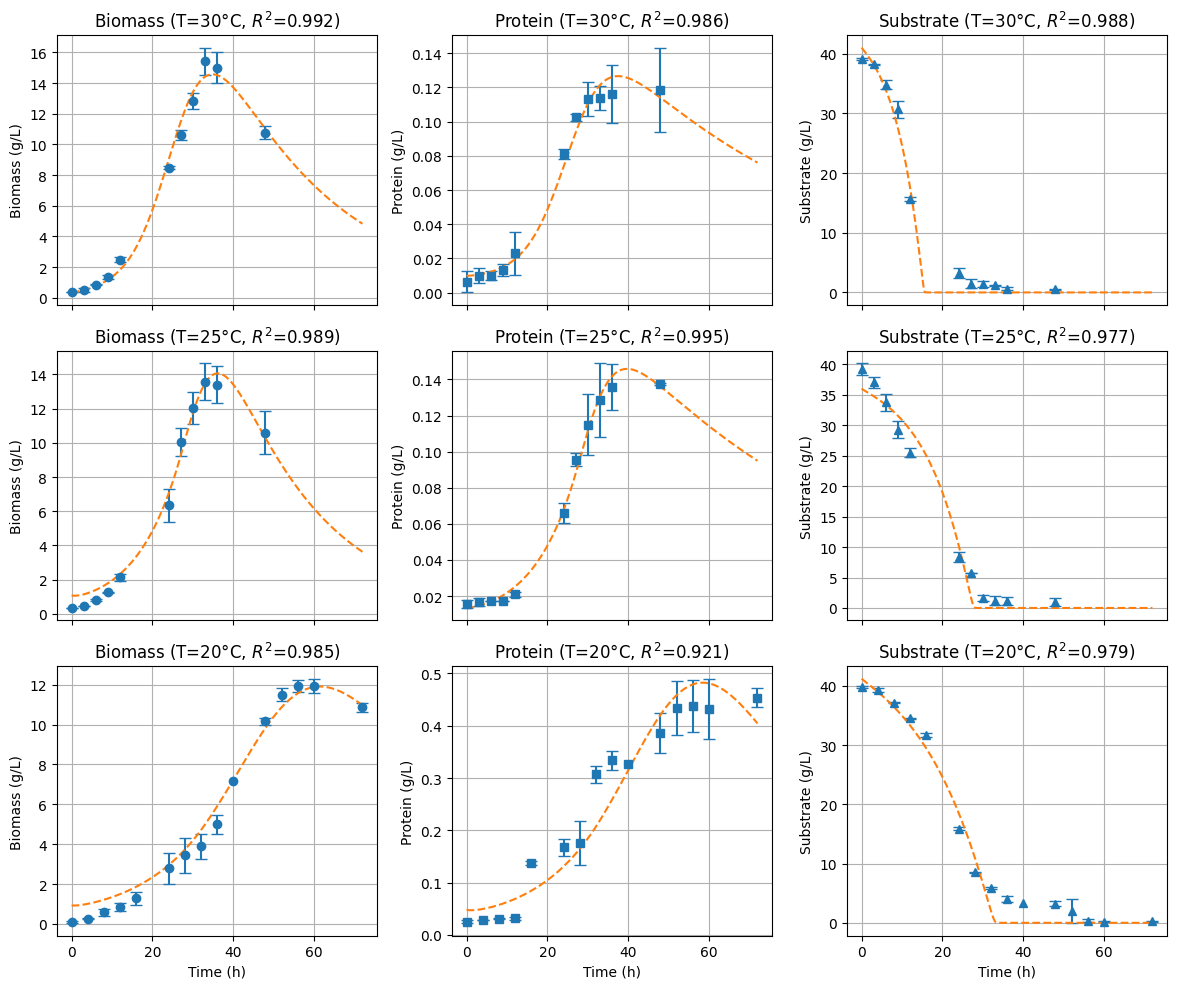

Coefficient of determination per variable and temperature:
variable  biomass  protein  substrate
T (°C)                               
30          0.992    0.986      0.988
25          0.989    0.995      0.977
20          0.985    0.921      0.979


In [3]:
# =============================================================================
# 3. Model–data comparison and goodness-of-fit (Fig. 2)
# =============================================================================
t_fine = np.linspace(0, max(mean_data(T)[0].max() for T in TEMPS), 500)
y_labels = ["Biomass (g/L)", "Protein (g/L)", "Substrate (g/L)"]
names = ["Biomass", "Protein", "Substrate"]
markers = ["o", "s", "^"]

R2_TABLE = []
fig, axs = plt.subplots(3, 3, figsize=(12, 10), sharex=True)
for i, T in enumerate(TEMPS):
    t, xd, Pd, Sd, ex, eP, eS = mean_data(T)
    fine = simulate(t_fine, BASE[T].params)[:3]      # trajectories on fine grid
    at_data = simulate(t, BASE[T].params)[:3]        # model at sampling times
    for j, (yd, ey) in enumerate([(xd, ex), (Pd, eP), (Sd, eS)]):
        r2 = r2_score(yd, at_data[j])
        R2_TABLE.append({"T (°C)": T, "variable": names[j].lower(), "R2": r2})
        ax = axs[i, j]
        ax.errorbar(t, yd, yerr=ey, fmt=markers[j], capsize=4)
        ax.plot(t_fine, fine[j], "--")
        ax.set_title(f"{names[j]} (T={T}°C, $R^2$={r2:.3f})")
        ax.set_ylabel(y_labels[j])
        ax.grid()
for ax in axs[-1]:
    ax.set_xlabel("Time (h)")
plt.tight_layout()
fig.savefig("figures/Fig2_model_fit_all_temperatures.png", dpi=300, bbox_inches="tight")
plt.show()

R2_TABLE = pd.DataFrame(R2_TABLE)
print("Coefficient of determination per variable and temperature:")
print(R2_TABLE.pivot(index="T (°C)", columns="variable", values="R2")
      .loc[TEMPS].round(3).to_string())

## 4. Goodness of fit beyond $R^2$ (Fig. S6 and Table S5)

$R^2$ alone is not an adequate measure of fit for dynamic models. This block computes, for each state variable and temperature, the variable-specific error metrics reported in **Supplementary Table S5**:

* **RMSE**, root-mean-square error, in the units of the variable;
* **NRMSE (mean)** and **NRMSE (range)**, the RMSE normalised by the mean and by the range (max − min) of the observations;
* **bias**, the mean signed difference (predicted − observed; a negative value means the model under-predicts), and the **relative bias** as a percentage of the observed mean.

It also generates **Supplementary Figure S6**: residuals (observed − predicted) versus time (top row) and observed versus predicted values with the 1:1 line (bottom row), for biomass, protein and substrate.

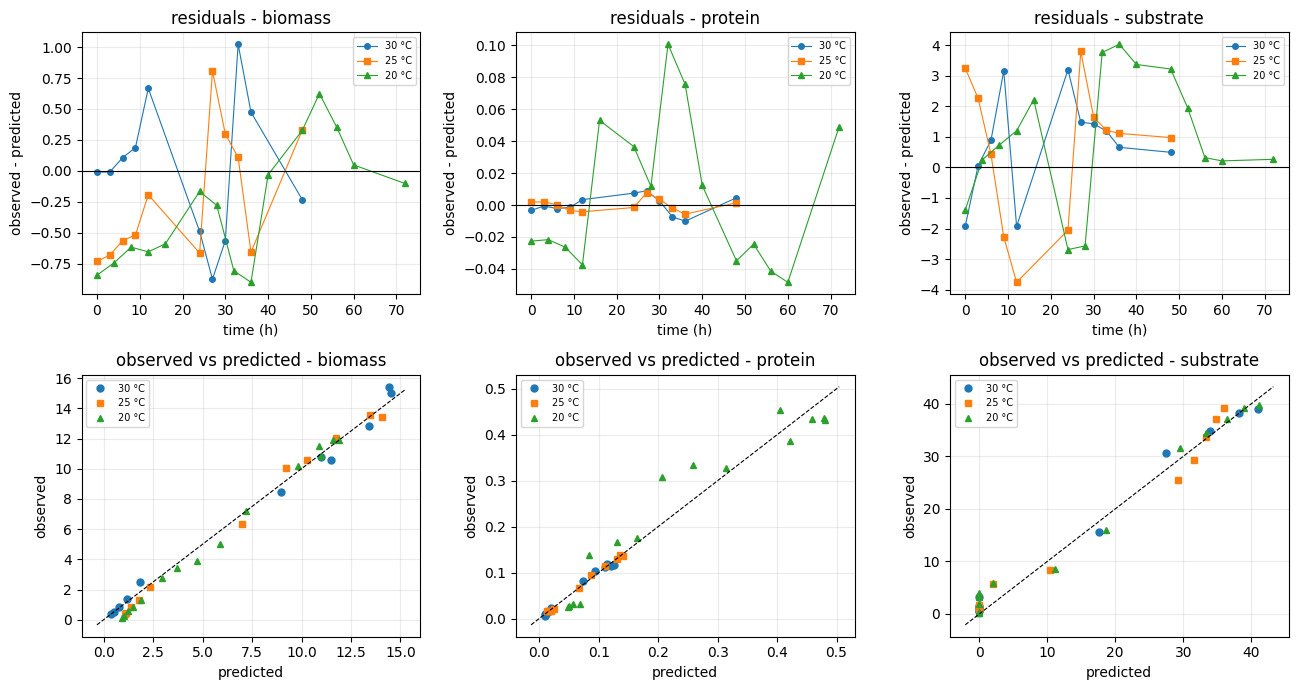

Supplementary Table S5 - variable-specific goodness-of-fit metrics
 T (°C)  variable     R2     RMSE  NRMSE mean (%)  NRMSE range (%)       bias  relative bias (%)
     30   biomass 0.9916   0.5341           7.469            3.544   -0.02556            -0.3575
     30   protein 0.9864 0.005634           8.753             5.03 -0.0001606            -0.2496
     30 substrate 0.9879    1.777           11.71            4.605    -0.7888               -5.2
     25   biomass 0.9892   0.5517           8.542            4.176     0.2235              3.461
     25   protein 0.9948 0.003677           5.284            3.014 -1.184e-06          -0.001701
     25 substrate 0.9768    2.338           13.99             6.11    -0.5981             -3.578
     20   biomass  0.985   0.5546           10.18            4.682     0.2913              5.347
     20   protein 0.9206  0.04594           18.58            10.73  -0.005442             -2.201
     20 substrate 0.9787    2.292           15.21           

In [4]:
# =============================================================================
# 4. Variable-specific error metrics and residual diagnostics (Fig. S6, Table S5)
# =============================================================================
rows = []
fig, axs = plt.subplots(2, 3, figsize=(13, 7))
for T, mk in zip(TEMPS, ["o", "s", "^"]):
    t, xd, Pd, Sd = mean_data(T)[:4]
    xm, Pm, Sm, _ = simulate(t, BASE[T].params)
    for j, (name, yd, ym) in enumerate([("biomass", xd, xm),
                                        ("protein", Pd, Pm),
                                        ("substrate", Sd, Sm)]):
        rmse = float(np.sqrt(np.mean((yd - ym) ** 2)))
        rows.append({"T (°C)": T, "variable": name, "R2": r2_score(yd, ym),
                     "RMSE": rmse,
                     "NRMSE mean (%)": 100 * rmse / np.mean(yd),
                     "NRMSE range (%)": 100 * rmse / (yd.max() - yd.min()),
                     "bias": float(np.mean(ym - yd)),
                     "relative bias (%)": 100 * np.mean(ym - yd) / np.mean(yd)})
        axs[0, j].plot(t, yd - ym, mk + "-", ms=4, lw=0.8, label=f"{T} °C")
        axs[1, j].plot(ym, yd, mk, ms=5, label=f"{T} °C")

for j, name in enumerate(["biomass", "protein", "substrate"]):
    axs[0, j].axhline(0, color="k", lw=0.8)
    axs[0, j].set_title(f"residuals - {name}")
    axs[0, j].set_xlabel("time (h)")
    axs[0, j].set_ylabel("observed - predicted")
    lim = axs[1, j].get_xlim()
    axs[1, j].plot(lim, lim, "k--", lw=0.8)
    axs[1, j].set_title(f"observed vs predicted - {name}")
    axs[1, j].set_xlabel("predicted")
    axs[1, j].set_ylabel("observed")
    for ax in axs[:, j]:
        ax.legend(fontsize=7)
        ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig("figures/FigS6_residual_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

GOF = pd.DataFrame(rows)
print("Supplementary Table S5 - variable-specific goodness-of-fit metrics")
print(GOF.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
GOF.to_csv("tables/TableS5_goodness_of_fit.csv", index=False)

## 5. Fitting the biological replicates explicitly (Table S2)

With $n = 2$ bioreactor cultures per temperature, fitting only the replicate-averaged curve could hide replicate-to-replicate variability or bias the estimates. This block fits the model in four ways and compares the results, generating **Supplementary Table S2**:

* **Mean-curve fit**: the reference fit of Table 1 (replicates averaged first, then fitted);
* **Pooled replicates**: one fit to all individual measurements of both replicates, without averaging;
* **Replicate 1 / Replicate 2**: each bioreactor run fitted independently.

Two summary columns are added: the **half-range** $|rep_1 - rep_2|/2$, the direct dispersion measure for $n = 2$, and the **deviation between the mean-curve and pooled fits**, $100\,|pooled - mean|/|mean|$, which tests whether averaging before fitting biases the estimates.

In [5]:
# =============================================================================
# 5. Fitting the biological replicates explicitly (Table S2)
# =============================================================================
rows = []
FIT_POOLED, FIT_PERREP = {}, {}
for T in TEMPS:
    reps = replicate_data(T)
    pooled = fit_droop(reps, GUESS[T])
    per = [fit_droop([d], GUESS[T]) for d in reps]
    FIT_POOLED[T], FIT_PERREP[T] = pooled, per
    for k in PKEYS:
        mean_fit = BASE[T].params[k].value
        pool_fit = pooled.params[k].value
        r1, r2 = (r.params[k].value for r in per)
        rows.append({"T (°C)": T, "parameter": k,
                     "mean-curve fit": mean_fit,
                     "pooled replicates": pool_fit,
                     "replicate 1": r1, "replicate 2": r2,
                     "half-range (n=2)": abs(r1 - r2) / 2,
                     "dev. mean vs pooled (%)":
                         100 * abs(pool_fit - mean_fit) / max(abs(mean_fit), 1e-12)})

TABLE_S2 = pd.DataFrame(rows)
print("Supplementary Table S2 - replicate-level fitting of the kinetic model")
print(TABLE_S2.to_string(index=False, float_format=lambda v: f"{v:.3g}"))
TABLE_S2.to_csv("tables/TableS2_replicate_fits.csv", index=False)
print("\nMaximum deviation between the mean-curve fit and the pooled-replicate fit: "
      f"{TABLE_S2['dev. mean vs pooled (%)'].max():.2f} %")

Supplementary Table S2 - replicate-level fitting of the kinetic model
 T (°C) parameter  mean-curve fit  pooled replicates  replicate 1  replicate 2  half-range (n=2)  dev. mean vs pooled (%)
     30      umax           0.201              0.201        0.198        0.202           0.00202                 9.04e-05
     30         m          0.0349             0.0349       0.0358       0.0341           0.00086                 6.01e-05
     30      qmax         0.00137            0.00137      0.00136      0.00142          3.16e-05                 0.000216
     30       m_P          0.0172             0.0172      0.00894       0.0277           0.00938                  0.00114
     30    rhomax             2.3                2.3         2.24          2.3            0.0327                 0.000169
     30        x0           0.369              0.369        0.397        0.355            0.0211                 0.000287
     30        P0          0.0099             0.0099      0.00466       0.01

## 6. Multi-start optimisation (Fig. S4)

A local least-squares optimiser can converge to a local minimum that depends on the initial guess. To test whether the estimates in Table 1 correspond to the global optimum, the fit is repeated 30 times per temperature from random initial guesses for the five kinetic parameters (drawn log-uniformly over wide ranges; the random seed is fixed in Block 2 for reproducibility).

For each temperature the block reports how many restarts reached the best objective value (within 0.1 %), the relative spread of the parameter estimates among those restarts, and how far above the optimum the remaining restarts ended. **Supplementary Figure S4** shows the sorted objective values (waterfall plot, log scale): a single flat plateau at the minimum indicates a unique, well-identified optimum, whereas separate steps reveal alternative local optima.

T = 30 °C | restarts converged: 30/30 | chi2 range: [0.29654, 0.29654] | restarts within 0.1% of the best: 30/30
    best parameter vector: umax=0.2008, m=0.03492, qmax=0.001372, m_P=0.01722, rhomax=2.297, x0=0.3692, P0=0.009904, S0=41
    max relative spread among near-best restarts (%): umax=0.001, m=0.000, qmax=0.001, m_P=0.007, rhomax=0.006, x0=0.008, P0=0.003, S0=0.000
    all restarts converged to the same optimum.

T = 25 °C | restarts converged: 30/30 | chi2 range: [0.32623, 0.45380] | restarts within 0.1% of the best: 24/30
    best parameter vector: umax=0.2169, m=0.04414, qmax=0.001571, m_P=0.01539, rhomax=0.3813, x0=1.08, P0=0.01365, S0=36
    max relative spread among near-best restarts (%): umax=0.124, m=0.084, qmax=0.026, m_P=0.264, rhomax=0.110, x0=0.292, P0=0.071, S0=0.017
    restarts that converged elsewhere: 6 (1% to 39% above the global optimum)

T = 20 °C | restarts converged: 30/30 | chi2 range: [1.02024, 1.02029] | restarts within 0.1% of the best: 30/30
    bes

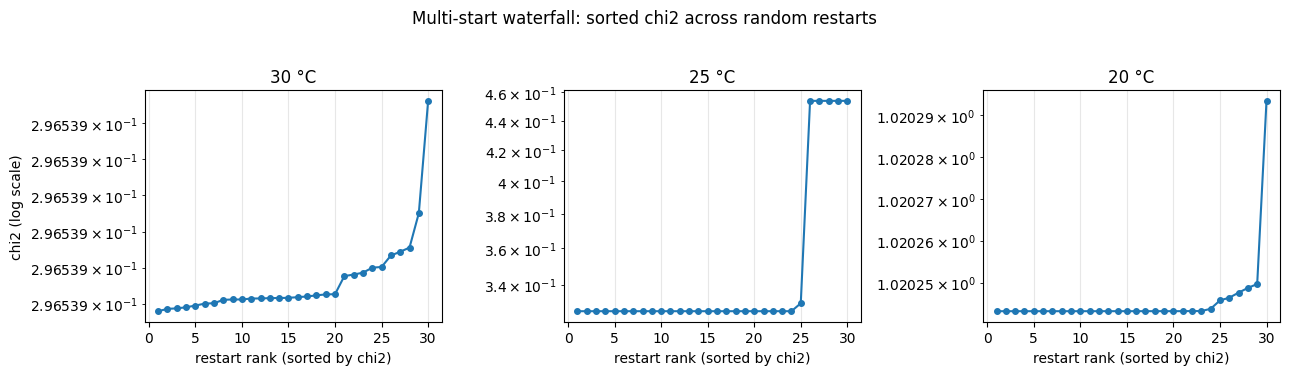

In [6]:
# =============================================================================
# 6. Multi-start optimisation: is the optimum unique? (Fig. S4)
# =============================================================================
MULTISTART = {}
for T in TEMPS:
    ds = [mean_data(T)[:4]]
    out = []
    for _ in range(N_MULTISTART):
        g = [10 ** RNG.uniform(np.log10(0.02), np.log10(0.5)),   # umax
             10 ** RNG.uniform(-3, -1),                          # m
             10 ** RNG.uniform(-4, -1),                          # qmax
             10 ** RNG.uniform(-3, -1),                          # m_P
             10 ** RNG.uniform(-1.3, 0.7)]                       # rhomax
        try:
            r = fit_droop(ds, g)
            out.append([r.chisqr] + [r.params[k].value for k in PKEYS])
        except Exception:
            pass
    M = np.array(sorted(out, key=lambda r: r[0]))
    MULTISTART[T] = M
    best = M[0, 0]
    near_best = M[M[:, 0] <= best * 1.001]
    n_best = len(near_best)

    print(f"T = {T} °C | restarts converged: {len(M)}/{N_MULTISTART} | "
          f"chi2 range: [{best:.5f}, {M[-1, 0]:.5f}] | "
          f"restarts within 0.1% of the best: {n_best}/{len(M)}")
    print("    best parameter vector:",
          ", ".join(f"{k}={v:.4g}" for k, v in zip(PKEYS, M[0, 1:])))
    if n_best > 1:
        pv = near_best[:, 1:]
        spread = 100 * (pv.max(axis=0) - pv.min(axis=0)) / np.abs(M[0, 1:])
        print("    max relative spread among near-best restarts (%):",
              ", ".join(f"{k}={s:.3f}" for k, s in zip(PKEYS, spread)))
    off = M[M[:, 0] > best * 1.001]
    if len(off):
        print(f"    restarts that converged elsewhere: {len(off)} "
              f"({100*(off[:,0].min()/best - 1):.0f}% to "
              f"{100*(off[:,0].max()/best - 1):.0f}% above the global optimum)")
    else:
        print("    all restarts converged to the same optimum.")
    print()

fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, T in zip(axs, TEMPS):
    chi2_sorted = MULTISTART[T][:, 0]
    ax.plot(np.arange(1, len(chi2_sorted) + 1), chi2_sorted, "o-", ms=4, color="tab:blue")
    ax.set_title(f"{T} °C")
    ax.set_xlabel("restart rank (sorted by chi2)")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
axs[0].set_ylabel("chi2 (log scale)")
plt.suptitle("Multi-start waterfall: sorted chi2 across random restarts", y=1.03)
plt.tight_layout()
fig.savefig("figures/FigS4_multistart_waterfall.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Profile likelihood of the kinetic parameters (Fig. S3)

Asymptotic standard errors rely on a linear approximation and do not by themselves establish practical identifiability. In a profile likelihood analysis, each kinetic parameter is fixed at 15 values spanning 0.3–2.5 × its optimal estimate while all the other parameters are re-optimised. The resulting objective value, normalised by its minimum ($\chi^2/\chi^2_{min}$), is plotted against the fixed value.

A narrow, approximately parabolic and bounded profile indicates a practically identifiable parameter; a flat profile indicates that the batch data do not constrain that parameter. This block generates **Supplementary Figure S3** (rows: temperature; columns: $\mu_{max}$, $m$, $q_{max}$, $m_P$, $\rho_{max}$; dashed vertical line: optimal estimate).

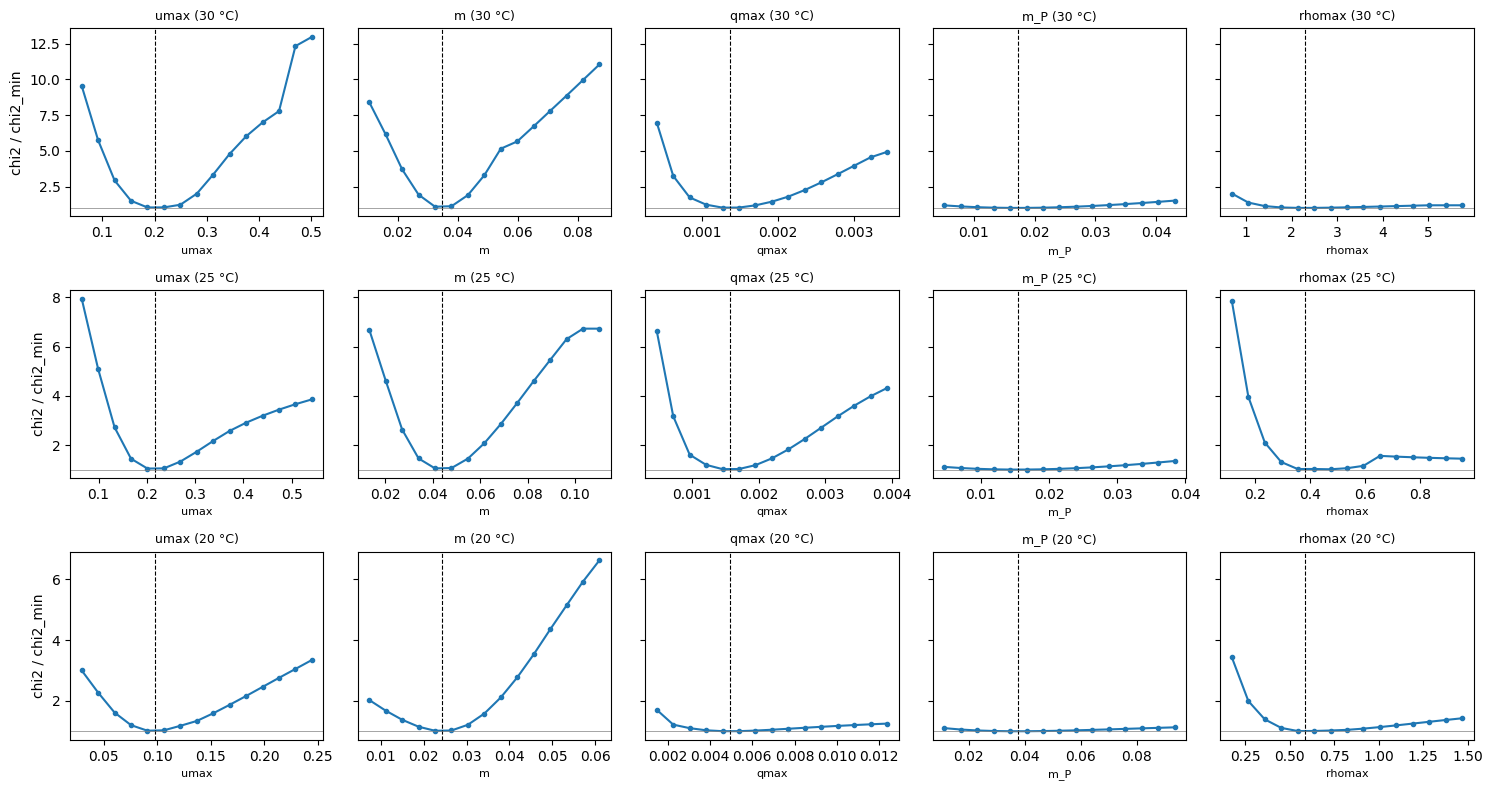

In [7]:
# =============================================================================
# 7. Profile likelihood of the kinetic parameters (Fig. S3)
# =============================================================================
PROFILES = {}
fig, axs = plt.subplots(3, 5, figsize=(15, 8), sharey="row")
for i, T in enumerate(TEMPS):
    ds = [mean_data(T)[:4]]
    p0 = {k: BASE[T].params[k].value for k in PKEYS}
    chi2_min = BASE[T].chisqr
    PROFILES[T] = {}
    for j, key in enumerate(KIN):
        grid = p0[key] * np.linspace(0.3, 2.5, N_PROFILE)
        prof = []
        for v in grid:
            pp = make_params([p0[k] for k in KIN], x0=p0["x0"], P0=p0["P0"], S0=p0["S0"])
            pp[key].set(value=v, vary=False)
            try:
                rr = lmfit.Minimizer(lambda q: residuals(q, ds), pp).minimize(method="leastsq")
                prof.append([v, rr.chisqr])
            except Exception:
                prof.append([v, np.nan])
        prof = np.array(prof)
        PROFILES[T][key] = prof
        ax = axs[i, j]
        ax.plot(prof[:, 0], prof[:, 1] / chi2_min, "-o", ms=3)
        ax.axvline(p0[key], color="k", ls="--", lw=0.8)
        ax.axhline(1.0, color="grey", lw=0.5)
        ax.set_title(f"{key} ({T} °C)", fontsize=9)
        ax.set_xlabel(key, fontsize=8)
        if j == 0:
            ax.set_ylabel("chi2 / chi2_min")
plt.tight_layout()
fig.savefig("figures/FigS3_profile_likelihood.png", dpi=300, bbox_inches="tight")
plt.show()

# Export the profiles
prof_rows = [{"T (°C)": T, "parameter": k, "value": v, "chi2": c,
              "chi2/chi2_min": c / BASE[T].chisqr}
             for T in TEMPS for k in KIN for v, c in PROFILES[T][k]]
pd.DataFrame(prof_rows).to_csv("tables/FigS3_profile_likelihood.csv", index=False)

## 8. Comparison with a conventional model (Fig. S5)

The Droop-type model is compared with a conventional unstructured model fitted independently to exactly the same replicate-averaged data and with the same normalised objective function. The conventional model combines Monod growth kinetics, a constant biomass yield on substrate $Y_{x/s}$ and Luedeking-Piret production kinetics (growth- and non-growth-associated terms):

$$
\dot x = (\mu - m)\,x,\quad \mu = \mu_{max}\frac{S}{S+K_S},\qquad
\dot P = (\alpha\mu + \beta)\,x,\qquad
\dot S = -\frac{\mu}{Y_{x/s}}\,x .
$$

$Y_{x/s}$ is first estimated directly from the batch data (biomass formed up to the biomass maximum divided by the substrate consumed up to that point) and used as the initial guess of the fitted yield. Both models have the same number of free parameters. The block reports $\chi^2$, AIC, BIC and $R^2$ for each model and the $\Delta$AIC in favour of the Droop-type model, and generates **Supplementary Figure S5** (conventional model fits with the model equations shown alongside).

Yxs estimated directly from the batch data:
  T = 30 °C : Yxs (data) = 0.398 g_X g_S-1
  T = 25 °C : Yxs (data) = 0.347 g_X g_S-1
  T = 20 °C : Yxs (data) = 0.299 g_X g_S-1

 T (°C)                   model  n par   chi2    AIC    BIC  Yxs_data  Yxs_fitted   R2_x   R2_P   R2_S
     30    Droop + cell quota z      8 0.2965 -139.5 -127.5       NaN         NaN 0.9916 0.9864 0.9879
     30 Monod + Luedeking-Piret      8  1.518 -85.62 -73.65    0.3977      0.3292 0.9218 0.9944  0.927
     25    Droop + cell quota z      8 0.3262 -136.3 -124.4       NaN         NaN 0.9892 0.9948 0.9768
     25 Monod + Luedeking-Piret      8  1.633 -83.21 -71.23    0.3473      0.2936 0.8807  0.951 0.9511
     20    Droop + cell quota z      8   1.02 -154.4 -139.9       NaN         NaN  0.985 0.9206 0.9787
     20 Monod + Luedeking-Piret      8  3.105 -104.3 -89.86    0.2991      0.2309 0.7881 0.9766 0.9532

Model comparison (Droop vs. Monod + Luedeking-Piret):
  T = 30 °C : delta AIC (Monod+LP - Droop) = 53.9


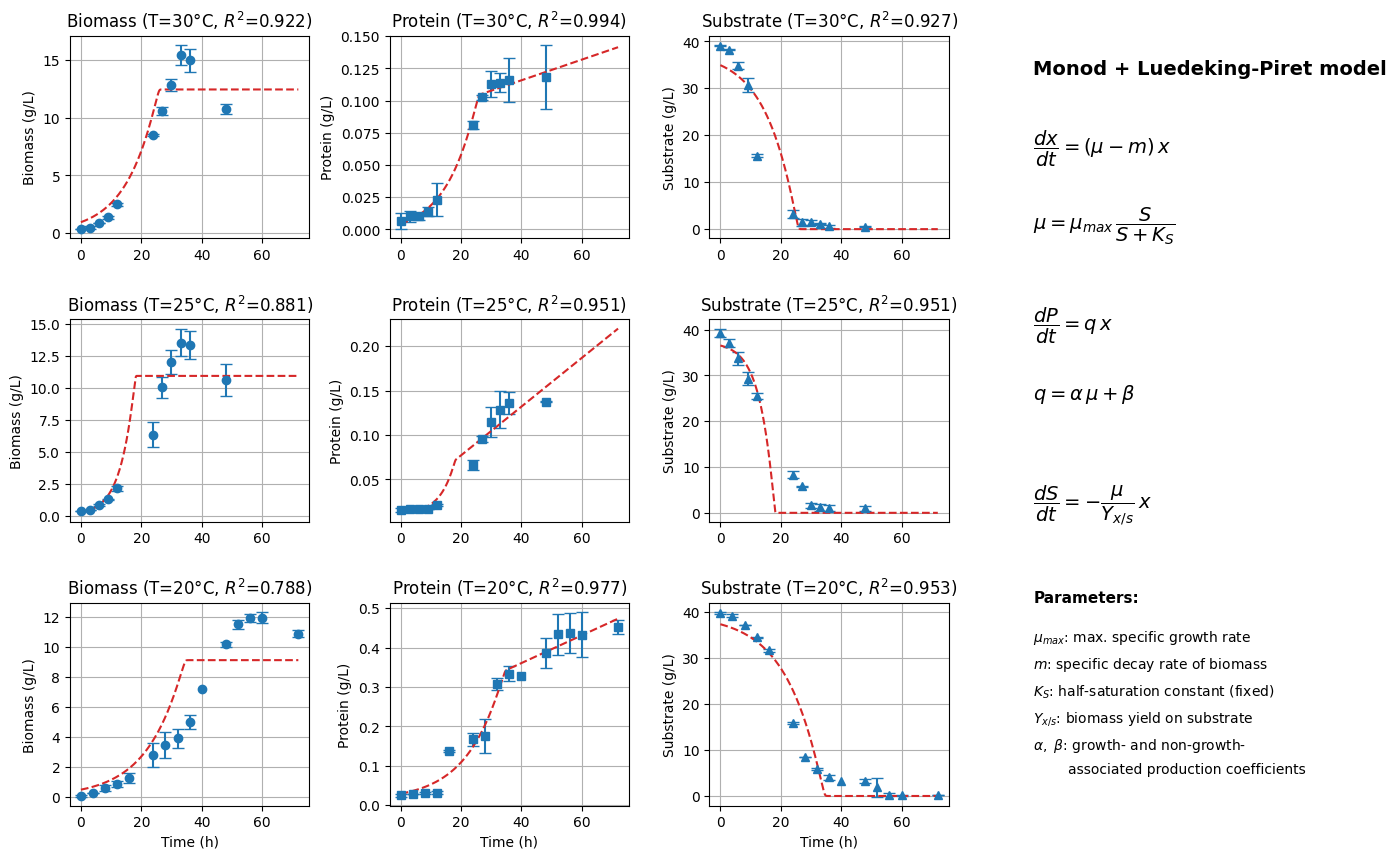

In [8]:
# =============================================================================
# 8. Comparison with a conventional Monod + Luedeking-Piret model (Fig. S5)
# =============================================================================
def compute_Yxs_from_data(t_data, x_data, S_data):
    """Biomass yield on substrate up to the biomass maximum (g_X / g_S)."""
    imax = np.argmax(x_data)
    dS = S_data[0] - S_data[imax]
    return (x_data[imax] - x_data[0]) / dS if dS > 0 else np.nan

YXS_DATA = {}
for T in TEMPS:
    t, xd, Pd, Sd = mean_data(T)[:4]
    YXS_DATA[T] = compute_Yxs_from_data(t, xd, Sd)
print("Yxs estimated directly from the batch data:")
for T in TEMPS:
    print(f"  T = {T} °C : Yxs (data) = {YXS_DATA[T]:.3f} g_X g_S-1")

def monod_lp_rhs(t, y, pv):
    x, P, S = y
    S = max(S, 0.0)
    mu = pv["umax"] * S / (S + pv["Ks"])
    q = pv["alpha"] * mu + pv["beta"]
    return [(mu - pv["m"]) * x, q * x, -(mu / pv["Yxs"]) * x]

def simulate_monod_lp(t_eval, params):
    pv = as_dict(params)
    t_eval = np.asarray(t_eval, float)
    s = solve_ivp(lambda tt, y: monod_lp_rhs(tt, y, pv), (t_eval[0], t_eval[-1]),
                  [pv["x0"], pv["P0"], pv["S0"]], t_eval=t_eval,
                  method="RK45", rtol=1e-7, atol=1e-9)
    return s.y

def fit_monod_lp(T):
    t, xd, Pd, Sd = mean_data(T)[:4]
    p = lmfit.Parameters()
    p.add("umax", value=0.2, min=0, max=1.0)
    p.add("m", value=0.02, min=0, max=0.1)
    p.add("Yxs", value=YXS_DATA[T], min=0.05, max=1.0)
    p.add("Ks", value=KS, vary=False)
    p.add("alpha", value=0.01, min=0, max=1.0)
    p.add("beta", value=1e-3, min=0, max=1.0)
    p.add("x0", value=xd[0], min=0, max=5.0)
    p.add("P0", value=Pd[0], min=0, max=1.0)
    p.add("S0", value=Sd[0], min=0, max=60.0)
    mx, mP, mS = xd.mean(), Pd.mean(), Sd.mean()
    def res(q):
        x, P, S = simulate_monod_lp(t, q)
        return np.concatenate([(xd - x) / mx, (Pd - P) / mP, (Sd - S) / mS])
    r = lmfit.Minimizer(res, p).minimize(method="leastsq")
    x, P, S = simulate_monod_lp(t, r.params)
    return r, dict(R2_x=r2_score(xd, x), R2_P=r2_score(Pd, P), R2_S=r2_score(Sd, S))

rows, MONOD_LP_FITS = [], {}
for T in TEMPS:
    t, xd, Pd, Sd = mean_data(T)[:4]
    xm, Pm, Sm, _ = simulate(t, BASE[T].params)
    rows.append({"T (°C)": T, "model": "Droop + cell quota z", "n par": BASE[T].nvarys,
                 "chi2": BASE[T].chisqr, "AIC": BASE[T].aic, "BIC": BASE[T].bic,
                 "Yxs_data": np.nan, "Yxs_fitted": np.nan,
                 "R2_x": r2_score(xd, xm), "R2_P": r2_score(Pd, Pm), "R2_S": r2_score(Sd, Sm)})
    r, mets = fit_monod_lp(T)
    MONOD_LP_FITS[T] = r
    rows.append({"T (°C)": T, "model": "Monod + Luedeking-Piret", "n par": r.nvarys,
                 "chi2": r.chisqr, "AIC": r.aic, "BIC": r.bic,
                 "Yxs_data": YXS_DATA[T], "Yxs_fitted": r.params["Yxs"].value, **mets})

MODELS = pd.DataFrame(rows)
print("\n" + MODELS.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
MODELS.to_csv("tables/FigS5_model_comparison.csv", index=False)

print("\nModel comparison (Droop vs. Monod + Luedeking-Piret):")
for T in TEMPS:
    sub = MODELS[MODELS["T (°C)"] == T].set_index("model")
    d = sub.loc["Monod + Luedeking-Piret", "AIC"] - sub.loc["Droop + cell quota z", "AIC"]
    print(f"  T = {T} °C : delta AIC (Monod+LP - Droop) = {d:.1f}")

# -----------------------------------------------------------------------------
# Figure S5: conventional model fits + model equations panel
# -----------------------------------------------------------------------------
t_fine = np.linspace(0, max(mean_data(T)[0].max() for T in TEMPS), 500)
y_labels = ["Biomass (g/L)", "Protein (g/L)", "Substrate (g/L)"]
names = ["Biomass", "Protein", "Substrate"]
markers = ["o", "s", "^"]
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(nrows=3, ncols=4, width_ratios=[1, 1, 1, 0.85],
                      hspace=0.40, wspace=0.35)
axs = np.empty((3, 3), dtype=object)
ax_ref = None
for i in range(3):
    for j in range(3):
        axs[i, j] = fig.add_subplot(gs[i, j], sharex=ax_ref)
        ax_ref = ax_ref or axs[i, j]

for i, T in enumerate(TEMPS):
    t, xd, Pd, Sd, ex, eP, eS = mean_data(T)
    r = MONOD_LP_FITS[T]
    fine = simulate_monod_lp(t_fine, r.params)
    at_data = simulate_monod_lp(t, r.params)
    for j, (yd, ey) in enumerate([(xd, ex), (Pd, eP), (Sd, eS)]):
        ax = axs[i, j]
        ax.errorbar(t, yd, yerr=ey, fmt=markers[j], capsize=4, color="tab:blue")
        ax.plot(t_fine, fine[j], "--", color="tab:red")
        ax.set_title(f"{names[j]} (T={T}°C, $R^2$={r2_score(yd, at_data[j]):.3f})")
        ax.set_ylabel(y_labels[j])
        ax.grid()
for ax in axs[-1]:
    ax.set_xlabel("Time (h)")

ax_eq = fig.add_subplot(gs[:, 3])
ax_eq.axis("off")
def eq_line(y, text, fontsize=14, weight="normal"):
    ax_eq.text(0.02, y, text, transform=ax_eq.transAxes, fontsize=fontsize,
               fontweight=weight, va="top", ha="left")
eq_line(0.97, "Monod + Luedeking-Piret model", weight="bold")
eq_line(0.88, r"$\dfrac{dx}{dt} = (\mu - m)\,x$")
eq_line(0.78, r"$\mu = \mu_{max}\,\dfrac{S}{S+K_S}$")
eq_line(0.65, r"$\dfrac{dP}{dt} = q\,x$")
eq_line(0.55, r"$q = \alpha\,\mu + \beta$")
eq_line(0.42, r"$\dfrac{dS}{dt} = -\dfrac{\mu}{Y_{x/s}}\,x$")
eq_line(0.28, "Parameters:", fontsize=11, weight="bold")
ax_eq.text(0.02, 0.23,
           r"$\mu_{max}$: max. specific growth rate" + "\n" +
           r"$m$: specific decay rate of biomass" + "\n" +
           r"$K_S$: half-saturation constant (fixed)" + "\n" +
           r"$Y_{x/s}$: biomass yield on substrate" + "\n" +
           r"$\alpha,\ \beta$: growth- and non-growth-" + "\n" +
           r"        associated production coefficients",
           transform=ax_eq.transAxes, fontsize=10, va="top", ha="left", linespacing=1.7)
fig.savefig("figures/FigS5_monod_lp_fit_all_temperatures.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Chemostat steady state and selection of dilution rates (Fig. 3)

The parameters estimated from the batch cultures are used to predict continuous (chemostat) operation. The chemostat balances add dilution terms to the batch model, with feed glucose concentration $S_{in} = 40$ g L⁻¹:

$$
\begin{aligned}
\dot x &= (\mu - m - D)\,x, &\qquad \dot P &= q\,x - (m_P + D)\,P,\\
\dot S &= D\,(S_{in} - S) - \rho\,x, & \dot z &= \rho - \mu\,z .
\end{aligned}
$$

**Steady-state criterion.** For each dilution rate $D$, the system is integrated in time from the batch initial conditions (with $S(0) = S_{in}$) until all time derivatives are negligible,

$$\max_i \frac{|dy_i/dt|}{|y_i|} < 10^{-8},$$

i.e. until $dy/dt \approx 0$. The integration horizon is extended automatically until this condition is met, so the result does not depend on an arbitrary final time. If biomass falls below $10^{-6}$ g L⁻¹ the culture is classified as washed out ($x^* = P^* = 0$). The steady-state volumetric productivity of total secreted protein is $Q_P = D\,P^*$.

From the steady-state curves the block reports, for each temperature, the dilution rate that maximises steady-state biomass, the dilution rate that maximises $Q_P$ ($D_{opt}$) and the critical (washout) dilution rate $D_{crit}$, located by bisection. It then generates **Fig. 3**: (A) steady-state biomass and (B) $Q_P$ versus $D$ at 20, 25 and 30 °C, with the dilution rates evaluated experimentally (0.025, 0.045 and 0.06 h⁻¹) marked on the 20 °C curve.

Model-predicted chemostat operating points (steady state: max|dy/dt|/|y| < 1e-08)
 T (°C)  umax (h-1)  D at max biomass (h-1)  x max (g/L)  D_opt (h-1)  QP max (g/L/h)  D_crit (h-1)  non-converged grid points
     30      0.2008                 0.04876        13.58      0.08899        0.007789        0.1496                          1
     25      0.2169                 0.05255        11.92      0.08054         0.00798       0.09353                          0
     20     0.09782                 0.02438           10      0.04332         0.01437       0.05938                          1
  note: T = 30 °C, D = 0.14953 h-1 lies within 7.0e-05 h-1 of D_crit; relaxation becomes extremely slow at the washout point, so max|dy/dt|/|y| = 9.1e-07 after 200000 h.
  note: T = 20 °C, D = 0.05932 h-1 lies within 6.1e-05 h-1 of D_crit; relaxation becomes extremely slow at the washout point, so max|dy/dt|/|y| = 4.0e-06 after 200000 h.

Predicted steady state at 20 °C for the dilution rates evaluated expe

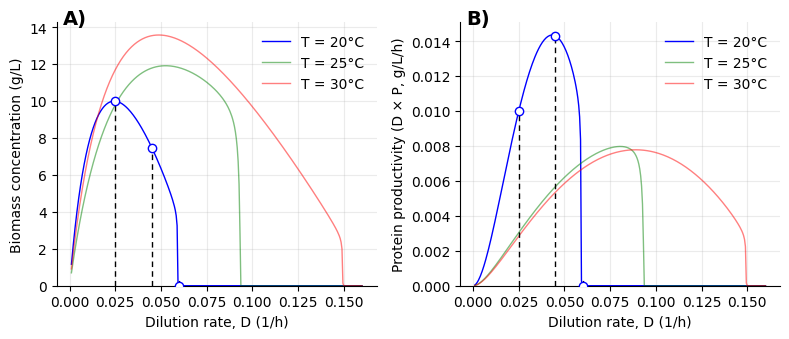

In [9]:
# =============================================================================
# 9. Chemostat steady state (dy/dt ≈ 0) and selection of dilution rates (Fig. 3)
# =============================================================================
from scipy.optimize import minimize_scalar

SS_TOL  = 1e-8      # steady-state criterion: max |dy/dt| / |y| < SS_TOL
X_WASH  = 1e-6      # g L-1: biomass below this value -> washout
T_FIRST = 200.0     # h: first integration window (doubled until convergence)
T_MAX   = 2e5       # h: safety limit for the integration horizon

def chemostat_rhs(t, y, pv, D, Sin):
    x, P, S, z = y
    S = max(S, 0.0)
    z = max(z, 1e-9)
    rho = pv["rhomax"] * S / (S + pv["Ks"])
    lim = 1.0 - pv["zmin"] / z
    mu = pv["umax"] * lim
    q  = pv["qmax"] * lim
    return np.array([(mu - pv["m"] - D) * x,
                     q * x - (pv["m_P"] + D) * P,
                     D * (Sin - S) - rho * x,
                     rho - mu * z])

def steady_state(p, D, Sin=None, tol=SS_TOL):
    """Integrate the chemostat model until max|dy/dt|/|y| < tol (dy/dt ≈ 0)."""
    pv = as_dict(p)
    Sin = SIN if Sin is None else Sin
    y = np.array([pv["x0"], pv["P0"], Sin, pv["z0"]], float)
    t, dt = 0.0, T_FIRST
    while True:
        sol = solve_ivp(chemostat_rhs, (t, t + dt), y, args=(pv, D, Sin),
                        method="LSODA", rtol=1e-10, atol=1e-12)
        y, t = sol.y[:, -1], sol.t[-1]
        if y[0] < X_WASH:                                   # washout
            return dict(x=0.0, P=0.0, S=Sin, z=y[3], QP=0.0, washout=True,
                        converged=True, t_ss=t, rel_dydt=np.nan)
        dy = chemostat_rhs(t, y, pv, D, Sin)
        rel = float(np.max(np.abs(dy) / np.maximum(np.abs(y), 1e-9)))
        if rel < tol or t >= T_MAX:
            return dict(x=y[0], P=y[1], S=y[2], z=y[3], QP=D * y[1], washout=False,
                        converged=rel < tol, t_ss=t, rel_dydt=rel)
        dt = min(2 * dt, T_MAX - t)

def critical_D(p, Sin=None, tol=1e-5):
    """Washout dilution rate, located by bisection on the washout condition."""
    pv = as_dict(p)
    lo, hi = 1e-4, pv["umax"] - pv["m"]          # growth impossible for D >= umax - m
    if steady_state(pv, lo, Sin)["washout"]:
        return np.nan
    while hi - lo > tol:
        mid = 0.5 * (lo + hi)
        if steady_state(pv, mid, Sin)["washout"]:
            hi = mid
        else:
            lo = mid
    return lo

def optimum_D(p, key="QP", Sin=None, n_coarse=60):
    """Dilution rate maximising a steady-state quantity (QP by default)."""
    pv = as_dict(p)
    Dc = critical_D(pv, Sin)
    Ds = np.linspace(1e-4, Dc, n_coarse)
    vals = np.array([steady_state(pv, D, Sin)[key] for D in Ds])
    i = int(np.argmax(vals))
    a, b = Ds[max(i - 1, 0)], Ds[min(i + 1, n_coarse - 1)]
    r = minimize_scalar(lambda D: -steady_state(pv, D, Sin)[key],
                        bounds=(a, b), method="bounded", options={"xatol": 1e-6})
    return r.x, -r.fun

# -----------------------------------------------------------------------------
# Steady-state curves for each temperature
# -----------------------------------------------------------------------------
D_grid = np.linspace(0.001, 0.16, 320)
CHEMO, SUMMARY = {}, []
for T in TEMPS:
    p = as_dict(BASE[T].params)
    ss = [steady_state(p, D) for D in D_grid]
    CHEMO[T] = pd.DataFrame(ss).assign(D=D_grid)
    D_xmax, x_max = optimum_D(p, key="x")
    D_opt, QP_max = optimum_D(p, key="QP")
    D_crit = critical_D(p)
    SUMMARY.append({"T (°C)": T, "umax (h-1)": p["umax"],
                    "D at max biomass (h-1)": D_xmax, "x max (g/L)": x_max,
                    "D_opt (h-1)": D_opt, "QP max (g/L/h)": QP_max,
                    "D_crit (h-1)": D_crit,
                    "non-converged grid points": int((~CHEMO[T]["converged"]).sum())})

SUMMARY = pd.DataFrame(SUMMARY)
print("Model-predicted chemostat operating points (steady state: max|dy/dt|/|y| < "
      f"{SS_TOL:g})")
print(SUMMARY.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
SUMMARY.to_csv("tables/Fig3_chemostat_operating_points.csv", index=False)
for T in TEMPS:
    nc = CHEMO[T][~CHEMO[T]["converged"]]
    for _, r in nc.iterrows():
        print(f"  note: T = {T} °C, D = {r['D']:.5f} h-1 lies within "
              f"{abs(r['D'] - SUMMARY.set_index('T (°C)').loc[T, 'D_crit (h-1)']):.1e} h-1 "
              f"of D_crit; relaxation becomes extremely slow at the washout point, "
              f"so max|dy/dt|/|y| = {r['rel_dydt']:.1e} after {r['t_ss']:.0f} h.")
pd.concat([CHEMO[T].assign(T=T) for T in TEMPS]).to_csv(
    "tables/Fig3_chemostat_steady_state_curves.csv", index=False)

# -----------------------------------------------------------------------------
# Steady state at the experimentally evaluated dilution rates (20 °C)
# -----------------------------------------------------------------------------
D_EXP = [0.025, 0.045, 0.060]
p20 = as_dict(BASE[20].params)
print("\nPredicted steady state at 20 °C for the dilution rates evaluated experimentally:")
for D in D_EXP:
    s = steady_state(p20, D)
    state = "WASHOUT" if s["washout"] else (
        f"x* = {s['x']:.3f} g/L | P* = {s['P']:.4f} g/L | S* = {s['S']:.3f} g/L | "
        f"QP = {s['QP']:.5f} g/L/h | reached after {s['t_ss']:.0f} h "
        f"(max|dy/dt|/|y| = {s['rel_dydt']:.1e})")
    print(f"  D = {D:.3f} h-1 : {state}")

# -----------------------------------------------------------------------------
# Figure 3: (A) steady-state biomass and (B) QP versus D
# -----------------------------------------------------------------------------
colors = {20: "blue", 25: "green", 30: "red"}
alpha_map = {20: 1.0, 25: 0.5, 30: 0.5}
fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), sharex=True)
for ax, key, ylab, tag in zip(axs, ["x", "QP"],
                              ["Biomass concentration (g/L)",
                               "Protein productivity (D × P, g/L/h)"],
                              ["A)", "B)"]):
    for T in [20, 25, 30]:
        ax.plot(CHEMO[T]["D"], CHEMO[T][key], color=colors[T], alpha=alpha_map[T],
                lw=1.0, label=f"T = {T}°C")
    for Dv in D_EXP:
        yv = steady_state(p20, Dv)[key]
        ax.vlines(Dv, 0.0, yv if yv > 0 else ax.get_ylim()[1] * 0.02,
                  colors="black", linestyles=(0, (4, 3)), lw=1.0)
        ax.plot(Dv, yv, "o", ms=6, mfc="white", mec=colors[20], mew=1.0, zorder=3)
    ax.set_xlabel("Dilution rate, D (1/h)")
    ax.set_ylabel(ylab)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False)
    ax.text(0.02, 1.05, tag, transform=ax.transAxes, fontsize=14,
            fontweight="bold", va="top", ha="left")
plt.tight_layout()
fig.savefig("figures/Fig3_selection_dilution_rates.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Model predictions vs. chemostat experimental data (Fig. 4)

This block compares the model predictions at 20 °C (Block 9, same $dy/dt \approx 0$ steady-state criterion) with the steady states measured in the chemostat cultures at $D$ = 0.025, 0.045 and 0.06 h⁻¹. For each dilution rate, three samples were taken during the steady state (residence times 3–5); their means correspond to **Supplementary Table S1** (biomass and total protein productivity).

The figure (**Fig. 4**) shows (A) steady-state biomass and (B) total secreted protein productivity $Q_P = D\,P$ as a function of $D$: the model curve, the individual samples and the mean ± SD of each steady state.

Because only three dilution rates were evaluated, a correlation coefficient is not an informative validation metric. The prediction error is therefore summarised with RMSE, normalised RMSE, bias and mean absolute percentage error (MAPE), computed with the mean of each steady state. Note that at $D$ = 0.06 h⁻¹ the batch-calibrated model lies beyond its predicted washout point ($D_{crit}$, Block 9), so the model predicts $x^* = Q_P = 0$ there; the metrics are therefore reported both for all three dilution rates and for the two rates inside the predicted operating range.

Chemostat steady states at 20 °C: observed (mean of n = 3) vs. predicted
 D (h-1)  x mean   x SD  P mean  QP mean     QP SD  x pred  P pred  QP pred  washout predicted
   0.025   14.97 0.1528  0.5297  0.01324 1.443e-05   9.998  0.4002     0.01              False
   0.045   11.03 0.4509  0.4517  0.02032 0.0005274   7.475  0.3183  0.01432              False
    0.06    6.17 0.1389   0.254  0.01524   0.00012       0       0        0               True


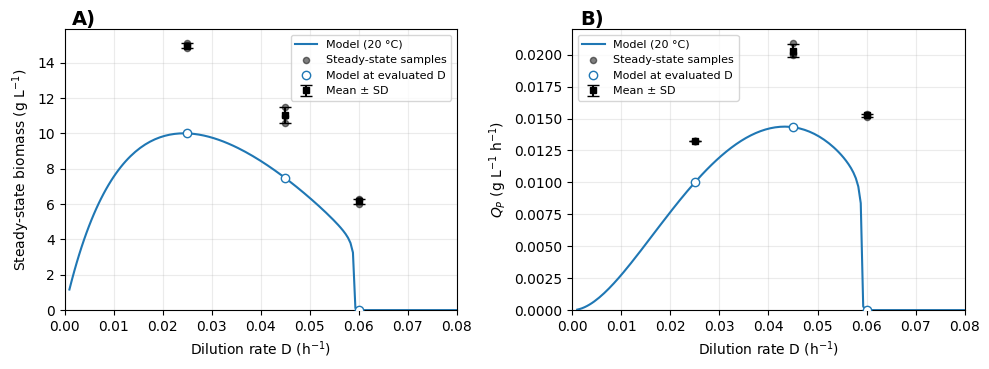


Prediction performance of the batch-calibrated model - all three dilution rates
  biomass: n = 3 | RMSE = 5.014 | NRMSE = 46.8 % | bias = -4.899 (-45.7 %) | MAPE = 55.1 %
  QP     : n = 3 | RMSE = 0.00964 | NRMSE = 59.3 % | bias = -0.00816 (-50.2 %) | MAPE = 51.3 %

Prediction performance - dilution rates below the predicted washout point (D = 0.025, 0.045 h-1)
  biomass: n = 2 | RMSE = 4.321 | NRMSE = 33.2 % | bias = -4.263 (-32.8 %) | MAPE = 32.7 %
  QP     : n = 2 | RMSE = 0.004822 | NRMSE = 28.7 % | bias = -0.00462 (-27.5 %) | MAPE = 27.0 %

Ranking of the conditions by QP
  observed : 0.045 > 0.060 > 0.025
  predicted: 0.045 > 0.025 > 0.060


In [10]:
# =============================================================================
# 10. Model predictions vs. chemostat experimental data (Fig. 4)
# =============================================================================
# Individual steady-state samples (n = 3 per dilution rate, residence times 3-5)
D_SS = [0.025, 0.045, 0.060]
x_groups = [[15.0, 14.8, 15.1], [11.5, 10.6, 11.0], [6.26, 6.24, 6.01]]        # g/L
P_groups = [[0.530, 0.529, 0.530], [0.465, 0.443, 0.447], [0.254, 0.252, 0.256]]  # g/L
QP_groups = [[D * Pv for Pv in Pg] for D, Pg in zip(D_SS, P_groups)]             # g/L/h

CHEMOSTAT = pd.DataFrame({
    "D (h-1)": D_SS,
    "x mean": [np.mean(g) for g in x_groups],
    "x SD": [np.std(g, ddof=1) for g in x_groups],
    "P mean": [np.mean(g) for g in P_groups],
    "QP mean": [np.mean(g) for g in QP_groups],
    "QP SD": [np.std(g, ddof=1) for g in QP_groups],
})
pred = [steady_state(p20, D) for D in D_SS]
CHEMOSTAT["x pred"] = [s["x"] for s in pred]
CHEMOSTAT["P pred"] = [s["P"] for s in pred]
CHEMOSTAT["QP pred"] = [s["QP"] for s in pred]
CHEMOSTAT["washout predicted"] = [s["washout"] for s in pred]
print("Chemostat steady states at 20 °C: observed (mean of n = 3) vs. predicted")
print(CHEMOSTAT.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
CHEMOSTAT.to_csv("tables/Fig4_chemostat_observed_vs_predicted.csv", index=False)

# -----------------------------------------------------------------------------
# Figure 4
# -----------------------------------------------------------------------------
D_exp_all = [D for D, g in zip(D_SS, x_groups) for _ in g]
x_all = [v for g in x_groups for v in g]
QP_all = [v for g in QP_groups for v in g]
curve = CHEMO[20]

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, key, obs_all, mean_col, sd_col, ylab, tag in [
        (axs[0], "x", x_all, "x mean", "x SD", "Steady-state biomass (g L$^{-1}$)", "A)"),
        (axs[1], "QP", QP_all, "QP mean", "QP SD", "$Q_P$ (g L$^{-1}$ h$^{-1}$)", "B)")]:
    ax.plot(curve["D"], curve[key], color="tab:blue", label="Model (20 °C)")
    ax.scatter(D_exp_all, obs_all, color="black", s=20, alpha=0.5, zorder=4,
               label="Steady-state samples")
    ax.errorbar(D_SS, CHEMOSTAT[mean_col], yerr=CHEMOSTAT[sd_col], fmt="s",
                color="black", ecolor="black", capsize=4, ms=5, zorder=5,
                label="Mean ± SD")
    ax.plot(D_SS, CHEMOSTAT[f"{key} pred"], "o", ms=6, mfc="white",
            mec="tab:blue", zorder=6, label="Model at evaluated D")
    ax.set_xlabel("Dilution rate D (h$^{-1}$)")
    ax.set_ylabel(ylab)
    ax.set_xlim(0, 0.08)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
    ax.text(0.02, 1.07, tag, transform=ax.transAxes, fontsize=14,
            fontweight="bold", va="top", ha="left")
plt.tight_layout()
fig.savefig("figures/Fig4_model_vs_chemostat.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------------------------------------------------------
# Prediction-error metrics
# -----------------------------------------------------------------------------
def prediction_metrics(obs, pred, label):
    o, p = np.asarray(obs, float), np.asarray(pred, float)
    rmse = float(np.sqrt(np.mean((p - o) ** 2)))
    print(f"  {label}: n = {len(o)} | RMSE = {rmse:.4g} | "
          f"NRMSE = {100*rmse/np.mean(o):.1f} % | bias = {np.mean(p-o):+.4g} "
          f"({100*np.mean(p-o)/np.mean(o):+.1f} %) | "
          f"MAPE = {100*np.mean(np.abs(p-o)/o):.1f} %")

inside = ~CHEMOSTAT["washout predicted"].to_numpy()
print("\nPrediction performance of the batch-calibrated model - all three dilution rates")
prediction_metrics(CHEMOSTAT["x mean"], CHEMOSTAT["x pred"], "biomass")
prediction_metrics(CHEMOSTAT["QP mean"], CHEMOSTAT["QP pred"], "QP     ")
print("\nPrediction performance - dilution rates below the predicted washout point "
      f"(D = {', '.join(f'{d:.3f}' for d in CHEMOSTAT['D (h-1)'][inside])} h-1)")
prediction_metrics(CHEMOSTAT["x mean"][inside], CHEMOSTAT["x pred"][inside], "biomass")
prediction_metrics(CHEMOSTAT["QP mean"][inside], CHEMOSTAT["QP pred"][inside], "QP     ")

print("\nRanking of the conditions by QP")
print("  observed :", " > ".join(f"{d:.3f}" for d in
      CHEMOSTAT.sort_values("QP mean", ascending=False)["D (h-1)"]))
print("  predicted:", " > ".join(f"{d:.3f}" for d in
      CHEMOSTAT.sort_values("QP pred", ascending=False)["D (h-1)"]))

## 11. Effect of the constants that were fixed (Tables S3 and S4)

The half-saturation constant $K_S$ and the initial cell quota $z_0$ cannot be identified from the batch data and were fixed ($K_S = 0.5$ g L⁻¹, $z_0 = z_{min} = 1$ g g⁻¹). This block quantifies how much the estimates and the model-based decision depend on that choice:

* **Table S3.** The model is refitted with $K_S$ fixed at 0.05–5 g L⁻¹ and, separately, with $z_0$ fixed at 1.0–2.0 g g⁻¹. For each refit, the objective value $J$ ($\chi^2$), the kinetic parameters and the predicted optimal dilution rate $D_{opt}$ are reported. $D_{opt}$ is computed with the same $dy/dt \approx 0$ steady-state criterion as in Block 9.
* **Table S4.** $z_{min}$ or $z_0$ is released as a free parameter. The block reports $J$ with the constant fixed and released, the relative change $\Delta\chi^2$, the change in AIC for releasing $z_{min}$ (one additional parameter; $|\Delta \mathrm{AIC}| < 2$ means no meaningful support), and the fitted value, flagging estimates that hit the upper bound of the search range (5 g g⁻¹).

In [11]:
# =============================================================================
# 11. Effect of the constants that were fixed (Tables S3 and S4)
# =============================================================================
def refit(T, **kw):
    return fit_droop([mean_data(T)[:4]], GUESS[T], **kw)

# -----------------------------------------------------------------------------
# Table S3: sensitivity to the fixed values of Ks and z0
# -----------------------------------------------------------------------------
rows = []
for const, values in [("Ks", [0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0]),
                      ("z0", [1.0, 1.05, 1.2, 1.5, 2.0])]:
    for T in TEMPS:
        for v in values:
            r = refit(T, **{const: v})
            p = as_dict(r.params)
            rows.append({"T (°C)": T, "fixed constant": const, "value": v,
                         "J": r.chisqr, **{k: p[k] for k in KIN},
                         "D_opt (h-1)": optimum_D(p)[0]})
TABLE_S3 = pd.DataFrame(rows)
print("Supplementary Table S3 - sensitivity to the fixed constants")
print(TABLE_S3.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
TABLE_S3.to_csv("tables/TableS3_fixed_constant_sensitivity.csv", index=False)

print("\nMaximum relative change across the tested range (%):")
for (T, const), g in TABLE_S3.groupby(["T (°C)", "fixed constant"], sort=False):
    ch = {k: 100 * (g[k].max() - g[k].min()) / abs(g[k].mean())
          for k in ["umax", "m", "qmax", "m_P", "D_opt (h-1)"]}
    print(f"  T = {T} °C, {const:<2}: " + ", ".join(f"{k} {v:.1f}" for k, v in ch.items()))

# -----------------------------------------------------------------------------
# Table S4: releasing zmin or z0 as free parameters
# -----------------------------------------------------------------------------
rows = []
for T in TEMPS:
    r0, r1 = BASE[T], refit(T, vary_zmin=True)
    v = r1.params["zmin"].value
    rows.append({"parameter released": "zmin", "T (°C)": T,
                 "J (fixed)": r0.chisqr, "J (free)": r1.chisqr,
                 "delta chi2 (%)": 100 * (r1.chisqr - r0.chisqr) / r0.chisqr,
                 "delta AIC": r1.aic - r0.aic, "fitted value (g/g)": v,
                 "note": "hits upper bound" if v >= r1.params["zmin"].max * 0.999 else ""})
for T in TEMPS:
    r0, r1 = BASE[T], refit(T, z0=1.2, vary_z0=True)
    v = r1.params["z0"].value
    rows.append({"parameter released": "z0", "T (°C)": T,
                 "J (fixed)": r0.chisqr, "J (free)": r1.chisqr,
                 "delta chi2 (%)": 100 * (r1.chisqr - r0.chisqr) / r0.chisqr,
                 "delta AIC": np.nan, "fitted value (g/g)": v,
                 "note": "hits upper bound (5.0)" if v >= 5.0 * 0.999 else ""})
TABLE_S4 = pd.DataFrame(rows)
print("\nSupplementary Table S4 - releasing zmin or z0 as free parameters")
print(TABLE_S4.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
TABLE_S4.to_csv("tables/TableS4_released_constants.csv", index=False)

Supplementary Table S3 - sensitivity to the fixed constants
 T (°C) fixed constant  value      J    umax       m     qmax     m_P  rhomax  D_opt (h-1)
     30             Ks   0.05 0.2953  0.2007 0.03488 0.001372 0.01721   2.261       0.0891
     30             Ks    0.1 0.2954  0.2007 0.03489 0.001372 0.01721   2.265      0.08909
     30             Ks   0.25 0.2959  0.2007  0.0349 0.001372 0.01722   2.277      0.08905
     30             Ks    0.5 0.2965  0.2008 0.03492 0.001372 0.01722   2.297      0.08899
     30             Ks      1 0.2979  0.2009 0.03495 0.001372 0.01723   2.337      0.08887
     30             Ks      2 0.3004   0.201 0.03502 0.001373 0.01724   2.417      0.08866
     30             Ks      5 0.3073  0.2014  0.0352 0.001373 0.01728   2.654      0.08811
     25             Ks   0.05 0.3399  0.2183 0.04436 0.001581  0.0155  0.3637      0.08628
     25             Ks    0.1 0.3383  0.2181 0.04434  0.00158 0.01549  0.3656      0.08486
     25             Ks   0.25 